<a href="https://colab.research.google.com/github/jesusessu/MDD-LAB06/blob/develop/MDD_LAB06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LABORATORIO 06**

Alumno:

Esplana Sulla Jesús Zósimo

**Parte A: Procesamiento de datos**

In [3]:
!pip install ucimlrepo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

In [5]:
# Combinar en un DataFrame
df = pd.concat([X, y], axis=1)

In [7]:
# Visualizar las primeras filas
display(df.head(10))

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
5,8,10,10,8,7,10.0,9,7,1,4
6,1,1,1,1,2,10.0,3,1,1,2
7,2,1,2,1,2,1.0,3,1,1,2
8,2,1,1,1,2,1.0,1,1,5,2
9,4,2,1,1,2,1.0,2,1,1,2


In [8]:
# información general del DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB
None


In [9]:
# Verificamos valores faltantes
print(df.isnull().sum())

# Si hay valores "?" como texto (común en datasets antiguos), los convertimos a NaN
df.replace("?", np.nan, inplace=True)

# Convertir columnas a numéricas si es necesario
df = df.apply(pd.to_numeric, errors='ignore')

# Volvemos a verificar valores faltantes
print(df.isnull().sum())

# Imputación: rellenar valores faltantes con la mediana de cada columna
df.fillna(df.median(numeric_only=True), inplace=True)

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


<ipython-input-9-491c4952a93b>:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [10]:
def detectar_outliers(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lim_inf, lim_inf,
                  np.where(df[col] > lim_sup, lim_sup, df[col]))
    return df

# Aplicamos a todas las columnas numéricas excepto la de clasificación
columnas_numericas = df.drop(columns=['Class']).select_dtypes(include=np.number).columns
df = detectar_outliers(df, columnas_numericas)

In [11]:
from sklearn.model_selection import train_test_split

# Separar variables
X = df.drop(columns=['Class'])
y = df['Class']

# Dividir en conjunto de entrenamiento y prueba (25% para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

**Parte B: Modelo k-NN y Métricas de Clasificación**

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

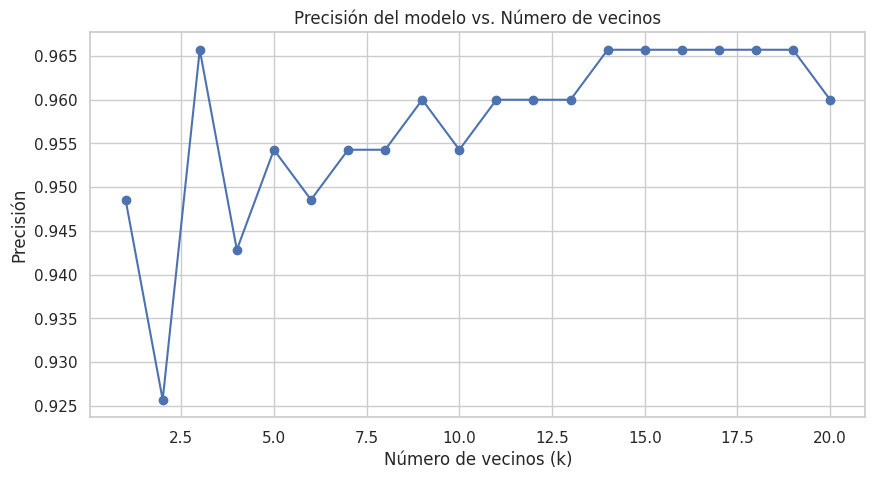

Mejor valor de k: 3


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Probar diferentes valores de k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Gráfico de precisión vs k
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión')
plt.title('Precisión del modelo vs. Número de vecinos')
plt.show()

# k óptimo
best_k = k_values[np.argmax(accuracies)]
print(f"Mejor valor de k: {best_k}")

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# Modelo final con mejor k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Matriz de confusión y reporte
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Matriz de Confusión:
[[111   4]
 [  2  58]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           2       0.98      0.97      0.97       115
           4       0.94      0.97      0.95        60

    accuracy                           0.97       175
   macro avg       0.96      0.97      0.96       175
weighted avg       0.97      0.97      0.97       175



**Parte C: Balanceo de clases con SMOTE**

In [15]:
from imblearn.over_sampling import SMOTE

# Aplicamos SMOTE solo al entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Distribución de clases después de SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Distribución de clases después de SMOTE:
Class
2    343
4    343
Name: count, dtype: int64


In [16]:
knn_smote = KNeighborsClassifier(n_neighbors=best_k)
knn_smote.fit(X_train_bal, y_train_bal)
y_pred_smote = knn_smote.predict(X_test_scaled)

# Métricas del modelo balanceado
print("Matriz de Confusión (SMOTE):")
print(confusion_matrix(y_test, y_pred_smote))

print("\nReporte de Clasificación (SMOTE):")
print(classification_report(y_test, y_pred_smote))

Matriz de Confusión (SMOTE):
[[111   4]
 [  1  59]]

Reporte de Clasificación (SMOTE):
              precision    recall  f1-score   support

           2       0.99      0.97      0.98       115
           4       0.94      0.98      0.96        60

    accuracy                           0.97       175
   macro avg       0.96      0.97      0.97       175
weighted avg       0.97      0.97      0.97       175

